# Jupyter Assignment 2, Vapor Power Plants

Mech 330, Fall 2025

Group #: 2
Student ID numbers: 20402193, 20411955
Names: Aslan Lauzon, Sanjana Sinha

In this project we will be designing the steam system for the new Small Modular Reactor (SMR) that is being constructed at the Darlington Nuclear Power Station, just down the 401 from us. The new reactor is estimated to be operational by 2028.

A nuclear power plant operates with the Rankine thermodynamic cycle with highly-controlled nuclear reactions providing heat. Some nuclear power plants have two 'loops', a primary loop which circulates liquid water at high pressure past nuclear fuel, and a secondary lower pressure loop which generates steam with a heat exchanger from the primary loop to feed into a turbine. These are called Pressurized Water Reactors (PWRs). [More info here on PWRs](https://en.wikipedia.org/wiki/Pressurized_water_reactor).

Other power plants have one 'loop', where water circulates past nuclear fuel and directly generates steam for use in the turbine. There are pros and cons of each design, but the new Darlington SMR uses the latter one loop design, also called a Boiling Water Reactor (BWR). [More info here on BWRs](https://en.wikipedia.org/wiki/Boiling_water_reactor).

The numbers here are a combination of what is publicly available for the power station found in the [Preliminary Safety Analysis Report](https://www.opg.com/documents/dnnp-bwrx-300-preliminary-safety-analysis-report-pdf/) with values missing estimated by myself.

Assignment questions have <font color='blue'>blue text</font> and empty code boxes beneath them.


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cantera as ct

### Problem 1: Basic Cycle

The nuclear designers have told us that their core produces 870MW of thermal energy (heat), with saturated steam leaving the core at a pressure of 7.2MPa.

To reduce system cost and complexity, we will start by analyzing a basic Rankine cycle. Below is a schematic of such a plant design. Note the non-standard numbering, this will ensure consistency as we build complexity. Please use the numbering listed in these schematics in your code.

Assume no pressure drop in the condenser (i.e., `P6 = P7`).

![](j2_basic.png)

<font color='blue'>1.1 Analyze the basic plant performance and determine the (a) overall first law efficiency, (b) turbine outlet quality, and (c) mass flow rate. (2 points)</font>

Givens are included in the code block below.

In [9]:
# Q1 Thermal efficiency of full plant & thermal power

### GIVENS ###
P1 = 7.2e6  # Pa
P2 = P1  # No pressure drop in nuclear reactor vessel
Q2 = 1  # outlet state is saturated steam (not superheated)
Q_dot_thermal = 870e6  # W, thermal output of nuclear fuel
eta_turbine = 0.9  # isentropic efficiency of turbine
T7 = 25 + 273.15  # K, outlet temperature from condenser
Q7 = 0  # outlet is saturated water (not subcooled)
eta_pump = 1  # isentropic efficiency of pump, not accurate, but pumps use very little power, so this makes our analysis a bit easier
w = ct.Water()

#state 1
P1 = 7.2e6


#state 2
P2 = P1
Q2 = 1 
w.PQ = P2, Q2
S2 = w.entropy_mass
h2 = w.enthalpy_mass
T2 = w.T

#state 6

#state 7
T7 = 25 + 273.15
Q7 = 0
w.TQ = T7, Q7
P7 = w.P
S7 = w.entropy_mass
h7 = w.enthalpy_mass
v7 = 1 / w.density_mass

#solve for state 6 pressure, enthalpy, entropy, quality
P6 = P7
S6s = S2
w.SP = (S6s,P6)
T6s = w.T
h6s = w.enthalpy_mass
Q6s = w.Q
h6 = eta_turbine * (h6s - h2) + h2
w.HP = h6, P6
S6 = w.entropy_mass
Q6 = w.Q
T6 = w.T





#solve for h1 using pump work
h1 =h7 + v7 * (P1 - P7) / eta_pump

#solve for s1
w.HP = h1, P1
S1 = w.entropy_mass
T1 = w.T


#solve rankine cycle efficiency
eta = ((h2-h6) - (h1-h7))/(h2-h1)
#solve for mass flow rate
m_dot = Q_dot_thermal / (h2-h1)


# Output
print(f'Plant efficiency: {eta:.3f}')  # First law efficiency, in fractional form
print(f'Turbine outlet quality: {Q6:.3f}')  # Quality at state 6
print(f'Mass flow: {m_dot:.1f} kg/s')  # 

Plant efficiency: 0.351
Turbine outlet quality: 0.706
Mass flow: 327.4 kg/s


In [ ]:
# Autograde test cell

<font color='blue'>1.2 Now plot the cycle on a T-s diagram, making sure to consider the isobaric process from 1$\rightarrow$2 and that the process from 2$\rightarrow$6 is unknown (use a dashed line). Label each state. A starter script to plot the vapordome is supplied. (1 point)</font>

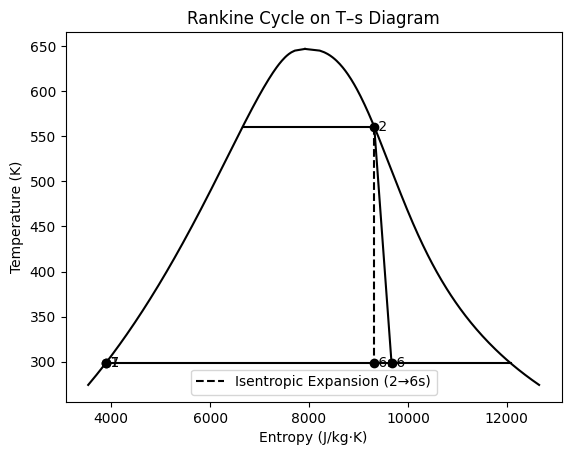

In [11]:
w = ct.Water()

def plot_vapordome():
    T_vapordome = np.linspace(274, 647.28, 200)
    s_left = np.zeros(len(T_vapordome))
    s_right = np.zeros(len(T_vapordome))

    for ii in range(len(T_vapordome)):
        w.TQ = T_vapordome[ii], 0
        s_left[ii] = w.s
        w.TQ = T_vapordome[ii], 1
        s_right[ii] = w.s

    plt.plot(s_left, T_vapordome, 'k-')
    plt.plot(s_right, T_vapordome, 'k-')
    plt.xlabel('Entropy (J/kg·K)')
    plt.ylabel('Temperature (K)')

plot_vapordome()


# Boiler path (P1)
q = np.linspace(0, 1, 80)
s_boiler, T_boiler = [], []
for qi in q:
    w.PQ = P1, qi
    s_boiler.append(w.s)
    T_boiler.append(w.T)

# Condenser path (P7)
q = np.linspace(1, 0, 60)
s_cond, T_cond = [], []
for qi in q:
    w.PQ = P7, qi
    s_cond.append(w.s)
    T_cond.append(w.T)

# ==== Plot cycle ====
plt.plot(s_boiler, T_boiler, 'k-')
plt.plot([S2, S6], [T2, T6], 'k-')
plt.plot(s_cond, T_cond, 'k-')
plt.plot([S7, S1], [T7, T1], 'k-')

# Dotted line to 6s state (isentropic expansion)
plt.plot([S2, S6s], [T2, T6s], 'k--', label='Isentropic Expansion (2→6s)')

# Points
for k,(sx,Tx) in {'1':(S1,T1),'2':(S2,T2),'6':(S6,T6),'7':(S7,T7),'6s':(S6s,T6s)}.items():
    plt.plot(sx, Tx, 'ko')
    plt.text(sx, Tx, f' {k}', va='center')

plt.title('Rankine Cycle on T–s Diagram')
plt.xlabel('Entropy (J/kg·K)')
plt.ylabel('Temperature (K)')
plt.legend()
plt.show()


### Problem 2: Reheat

You should have found that the outlet turbine quality is relatively low (around 0.7). This can lead to turbine operability challenges. To remedy this, you propose a reheat step. Because we want to make as few penetrations to the reactor vessel as possible, we just use some of the outlet steam to reheat.

Assume that the high-pressure outlet of the reheater (State 10) is saturated liquid. Note that this isn't a particularly good assumption (and is unphysical for high values of $\dot{m}_9$), but it eases our analysis considerably.

We need to determine what mass flow rate to extract from the reactor outlet stream to ensure that the quality in both turbines remains above 0.8.

![](j2_reheat.png)

<font color='blue'>2.1 Repeat your plant analysis, now with the reheat step, as a function of the ratio of $\dot{m}_9/\dot{m}_1$, from 0 to 0.25. Plot plant efficiency and low pressure and high pressure turbine outlet qualities as a function of $\dot{m}_9/\dot{m}_1$. (3 points)</font>

Hint: Your efficiency and LPT turbine quality for $\dot{m}_9/\dot{m}_1=0$ should be similar but not identical to Part 1, because of how isentropic efficiency is defined.

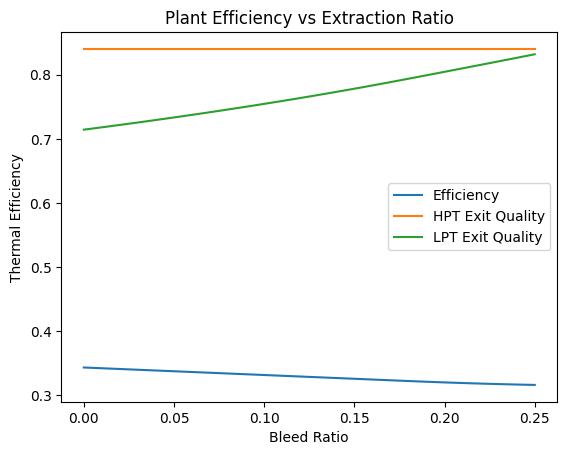

In [12]:
# Q1 Thermal efficiency of full plant & thermal power

def calcRankine(m_dot_ratio):
    
    P1 = 7.2e6  # Pa
    P2 = P1  # No pressure drop in nuclear reactor vessel
    P10 = P2  # No pressure drop in reheater
    Q2 = 1
    P4 = 1e6  # Pa
    Q_dot_thermal = 870e6  # W, thermal output of nuclear fuel
    eta_turbine = 0.9  # isentropic efficiency of BOTH turbines
    T7 = 25 + 273.15  # K, outlet temperature from condenser
    Q7 = 0  # outlet is saturated water (not subcooled)
    eta_pump = 1  # isentropic efficiency of pump, not accurate, but pumps use very little power, so this makes our analysis a bit easier
    w = ct.Water()


    results_eta = []
    results_Q4 = []
    results_Q6 = []

    for ratio in m_dot_ratio:
        # State 2
        w.PQ = P2, Q2
        S2 = w.entropy_mass
        h2 = w.enthalpy_mass

        # State 3 (same as 2)
        h3 = h2

        # State 4s (isentropic expansion to P4)
        w.SP = (w.entropy_mass, P4)
        h4s = w.enthalpy_mass
        h4 = eta_turbine * (h4s - h3) + h3
        w.HP = h4, P4
        Q4 = w.Q

        # State 9 (extracted steam, same as 3)
        h9 = h3
        # State 10 (saturated liquid at P10)
        Q10 = 0
        w.PQ = P10, Q10
        h10 = w.enthalpy_mass

        h5 = h4 + (ratio * (h9 - h10)) / (1 - ratio)
        w.HP = (h5, P4)
        s5 = w.entropy_mass

        # State 6 (isentropic expansion to P6)
        w.SP = (w.entropy_mass, P6)
        h6s = w.enthalpy_mass
        h6 = eta_turbine * (h6s - h2) + h2
        w.HP = h6, P6
        Q6 = w.Q

        #state 7
        w.TQ = (T7, 0)
        h7 = w.enthalpy_mass
        S7 = w.entropy_mass
        P7 = w.P

        # State 1 (pump)
        h1 = h7 + v7 * (P1 - P7) / eta_pump

        # Mass flow rate
        m_dot = Q_dot_thermal / (h2 - h1)

        # Efficiency
        eta = m_dot * ((1 - ratio) * ((h3 - h4) + (h5 - h6)) - (h1 - h7)) / Q_dot_thermal

        results_eta.append(eta)
        results_Q4.append(Q4)
        results_Q6.append(Q6)

    return np.array(results_eta), np.array(results_Q4), np.array(results_Q6)

m_dot_ratio = np.linspace(0,0.25,50)
eta, Q4, Q6 = calcRankine(m_dot_ratio)
plt.plot(m_dot_ratio, eta, label='Efficiency')
plt.plot(m_dot_ratio, Q4, label='HPT Exit Quality')
plt.plot(m_dot_ratio, Q6, label='LPT Exit Quality')
plt.xlabel('Bleed Ratio')
plt.ylabel('Thermal Efficiency')
plt.title('Plant Efficiency vs Extraction Ratio')
plt.legend()
plt.show()









<font color='blue'> 2.2 You should have found that thermal efficiency decreases with increasing $\dot{m}_9$. Why? (1 point)

In this confirguration the bleed is before the HPT, meaning that with a greater bleed less the gas does not enter the turbine at all, resulting in greater internal losses and a lower efficiency

<font color='blue'> 2.3 Plot the new cycle on a T-s diagram for $\dot{m}_9/\dot{m}_1 = 0.25$. (1 point)</font>

Omit states 9-12 for simplicity.


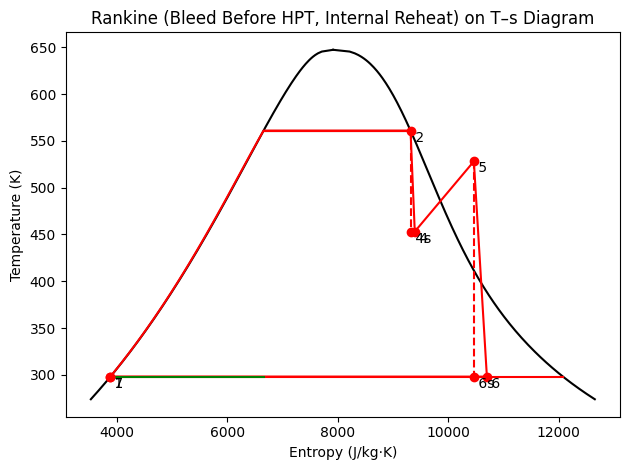

In [17]:
plot_vapordome()

m_dot_ratio = 0.25
    
P1 = 7.2e6  # Pa
P2 = P1  # No pressure drop in nuclear reactor vessel
P10 = P2  # No pressure drop in reheater
Q2 = 1
P4 = 1e6  # Pa
Q_dot_thermal = 870e6  # W, thermal output of nuclear fuel
eta_turbine = 0.9  # isentropic efficiency of BOTH turbines
T7 = 25 + 273.15  # K, outlet temperature from condenser
Q7 = 0  # outlet is saturated water (not subcooled)
eta_pump = 1  # isentropic efficiency of pump, not accurate, but pumps use very little power, so this makes our analysis a bit easier
w = ct.Water()


results_eta = []
results_Q4 = []
results_Q6 = []

# State 2
w.PQ = P2, Q2
S2 = w.entropy_mass
h2 = w.enthalpy_mass

# State 3 (same as 2)
h3 = h2

# State 4s (isentropic expansion to P4)
w.SP = (w.entropy_mass, P4)
h4s = w.enthalpy_mass
S4s = w.entropy_mass
T4s = w.T
h4 = eta_turbine * (h4s - h3) + h3
w.HP = h4, P4
Q4 = w.Q
S4 = w.entropy_mass
T4 = w.T


# State 9 (extracted steam, same as 3)
h9 = h3

# State 10 (saturated liquid at P10)
Q10 = 0
w.PQ = P10, Q10
h10 = w.enthalpy_mass

h5 = h4 + (m_dot_ratio * (h9 - h10)) / (1 - m_dot_ratio)
w.HP = (h5, P4)
S5 = w.entropy_mass
T5 = w.T


# State 6 (isentropic expansion to P6)
w.SP = (S5, P6)
S6s = S5
h6s = w.enthalpy_mass
T6s = w.T
h6 = eta_turbine * (h6s - h2) + h2
w.HP = h6, P6
Q6 = w.Q
T6 = w.T
S6 = w.entropy_mass



#state 7
w.TQ = (T7, 0)
h7 = w.enthalpy_mass
S7 = w.entropy_mass
P7 = w.P

# State 1 (pump)
h1 = h7 + v7 * (P1 - P7) / eta_pump

w.TQ = (T2, 0)
S_liqP2 = w.entropy_mass

w.TQ = (T1, 0)
T_liqP2 = w.T


plt.plot(s_boiler, T_boiler, 'k-')

# Red line for isobaric heating from point 1 up to point 2 (boiler line)
plt.plot(s_boiler, T_boiler, 'r-', label='Isobaric 1→2')


# HPT (2 → 4), Internal Reheat (4 → 5), LPT (5 → 6)
plt.plot([S2, S4], [T2, T4], 'r-')     # real HPT
plt.plot([S4, S5], [T4, T5], 'r-')     # internal reheat at P4
plt.plot([S5, S6], [T5, T6], 'r-')     # real LPT

# Condenser isobar (6 → 7)
plt.plot(s_cond, T_cond, 'r-')

# 6 → 1 is a straight line
plt.plot([S6, S1], [T6, T1], 'r-', label='6→1 (liquid return)')

# Pump (7 → 1)
plt.plot([S7, S1], [T7, T1], 'r-')

# Dotted isentropic guides
plt.plot([S2, S2], [T2, T4s], 'r--', label='Isentropic HPT (2→4s)')
plt.plot([S5, S6s], [T5, T6s], 'r--', label='Isentropic LPT (5→6s)')

plt.plot([S1, S_liqP2], [T1, T_liqP2], 'g-', label='Isobaric heating 1→2 (liquid line)')


# Points & labels
points = {
    '1': (S1, T1),
    '2': (S2, T2),
    '4': (S4, T4),
    '5': (S5, T5),
    '6': (S6, T6),
    '7': (S7, T7),
    '4s': (S2, T4s),
    '6s': (S6s, T6s),
}
for k, (sx, Tx) in points.items():
    plt.plot(sx, Tx, 'ro')
    plt.text(sx, Tx, f' {k}', va='top')

s12 = np.linspace(S1,S2)
T12 = np.zeros(len(s12))

for i in range(len(s12)):
    w.SP = (s12[i], P1)
    T12[i] = w.T
plt.plot(s12, T12, 'r-')

plt.title('Rankine (Bleed Before HPT, Internal Reheat) on T–s Diagram')
plt.xlabel('Entropy (J/kg·K)')
plt.ylabel('Temperature (K)')
plt.tight_layout()
plt.show()

### Problem 3: Feedwater heating - BONUS

<font color='red'>You do not need to complete this problem for full credit. Correct answers to this problem will be for bonus points (3 points total) to those interested.</font>

We have solved the turbine steam quality problem, but lost efficiency in doing so. To get it back, you propose incorporating a closed feedwater heater to preheat the core inlet.

We will assume that State 11 is 5K higher than State 8, a reasonable assumption for a counter-flow heat exchanger.

![](j2_fwh.png)

<font color='blue'>3.1 Repeat your plant analysis, now with the reheat and feedwater step, as a function of $\dot{m}_9/\dot{m}_1$, from 0 to 0.25. Plot plant efficiency as a function of $\dot{m}_9/\dot{m}_1$ for the new configuration with a feedwater heater and compare it to the old configuration with a reheater only. (2 points)</font>

Hint: To solve for state 1, write down the first law for the feedwater heater, and consider that states 8, 10, and 11 can all be determined from assumptions.

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

You should see that we've gotten most of our efficiency back with the feedwater heater.

<font color='blue'> 3.2 Plot the new cycle on a T-s diagram for $\dot{m}_9/\dot{m}_1 = 0.25$. (1 point)</font>

In [ ]:
# YOUR CODE HERE
raise NotImplementedError()